# 📈 Regression Analysis
## Predicting Number of Prior Convictions
### COMPAS Recidivism Dataset

### What we will cover:
1. **Linear Regression** — baseline model
2. **Residual Analysis** — checking model assumptions
3. **Log Transform** — improving skewed targets
4. **Ridge Regression** — L2 regularization
5. **Lasso Regression** — L1 regularization (feature selection)
6. **Cross-Validation** — robust model evaluation

In [2]:
# Cell 1 - Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print("All libraries imported successfully!")

All libraries imported successfully!


Target variable — Prior Convictions:
Mean: 3.47
Median: 2.00
Min: 0
Max: 38
Std: 4.88


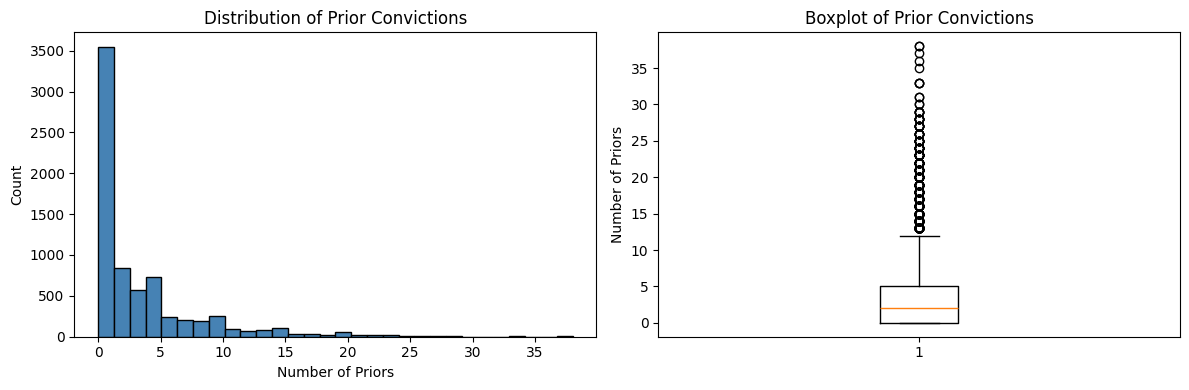

In [3]:
# Cell 2 - Load and prepare data
df = pd.read_csv(r'C:\Users\fo2225\criminal_justice_app\compas.csv')
df = df[['age', 'sex', 'race', 'priors_count', 'c_charge_degree', 'two_year_recid']].dropna()

# One-hot encode categorical variables
df = pd.get_dummies(df, columns=['sex', 'race', 'c_charge_degree'])

# Target is now priors_count (continuous number)
X = df.drop('priors_count', axis=1)
y = df['priors_count']

print("Target variable — Prior Convictions:")
print(f"Mean: {y.mean():.2f}")
print(f"Median: {y.median():.2f}")
print(f"Min: {y.min()}")
print(f"Max: {y.max()}")
print(f"Std: {y.std():.2f}")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Prior Convictions')
axes[0].set_xlabel('Number of Priors')
axes[0].set_ylabel('Count')

axes[1].boxplot(y)
axes[1].set_title('Boxplot of Prior Convictions')
axes[1].set_ylabel('Number of Priors')

plt.tight_layout()
plt.show()

## 📊 Target Variable Analysis — Prior Convictions

### Key Statistics:
- **Mean: 3.47** but **Median: 2.0** — big difference signals skewness
- **Range: 0 to 38** — very wide spread
- **Std: 4.88** — high variability

### What the charts show:
- **Heavily right-skewed** — most people have 0-5 priors
- **Long tail** — small number of people with 15-38 priors
- **Many outliers** in the boxplot (circles above the whisker)

### Why this matters for regression:
Linear regression assumes the target is roughly normally distributed.
With this skewed distribution our model will:
- Predict low values well (lots of data there)
- Struggle with high values (few examples)

### Solution — Log Transform:
We can apply log(y+1) to compress the scale and make it 
more normal. We'll compare results with and without this transform.

In [4]:
# Cell 3 - Linear Regression Baseline
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Evaluate
y_pred = lr.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=== Linear Regression Baseline ===")
print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"\nInterpretation:")
print(f"R²={r2:.3f} means the model explains {r2:.1%} of variance in prior convictions")
print(f"RMSE={rmse:.3f} means predictions are off by {rmse:.1f} priors on average")

=== Linear Regression Baseline ===
R² Score: 0.199
RMSE: 4.329

Interpretation:
R²=0.199 means the model explains 19.9% of variance in prior convictions
RMSE=4.329 means predictions are off by 4.3 priors on average


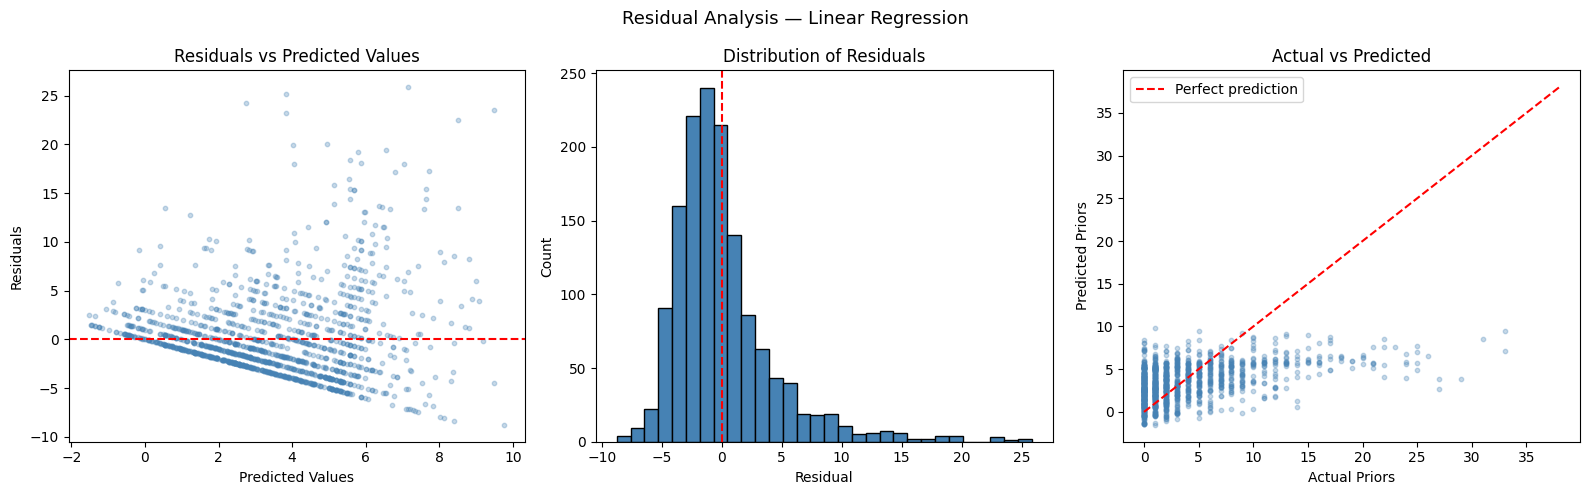

In [5]:
# Cell 4 - Residual Analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.3, color='steelblue', s=10)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

# Distribution of residuals
axes[1].hist(residuals, bins=30, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--')
axes[1].set_title('Distribution of Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')

# Actual vs Predicted
axes[2].scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
axes[2].plot([0, 38], [0, 38], color='red', linestyle='--', label='Perfect prediction')
axes[2].set_title('Actual vs Predicted')
axes[2].set_xlabel('Actual Priors')
axes[2].set_ylabel('Predicted Priors')
axes[2].legend()

plt.suptitle('Residual Analysis — Linear Regression', fontsize=13)
plt.tight_layout()
plt.show()

## 🔍 Residual Analysis — What's Wrong with the Model?

### Left Chart — Residuals vs Predicted:
- Residuals should be randomly scattered around 0 (red line)
- Instead we see a **fan shape** — residuals get bigger as predictions increase
- This is called **heteroscedasticity** — the model is less accurate for higher values
- This violates a key assumption of linear regression

### Middle Chart — Distribution of Residuals:
- Should be a normal bell curve centered at 0
- Instead it is **right skewed** with a long tail
- The model consistently underestimates high values

### Right Chart — Actual vs Predicted:
- Points should follow the red diagonal line closely
- For low values (0-5 priors) predictions are reasonable
- For high values (15-38 priors) the model completely fails
- It never predicts above ~10 priors even when actual is 38!

### Root Cause:
The skewed target distribution is causing all these problems.
The model is "pulled" toward the many low-prior cases and 
ignores the high-prior outliers.

### Solution:
Apply **log transform** to the target variable to compress 
the scale and make it more normal.

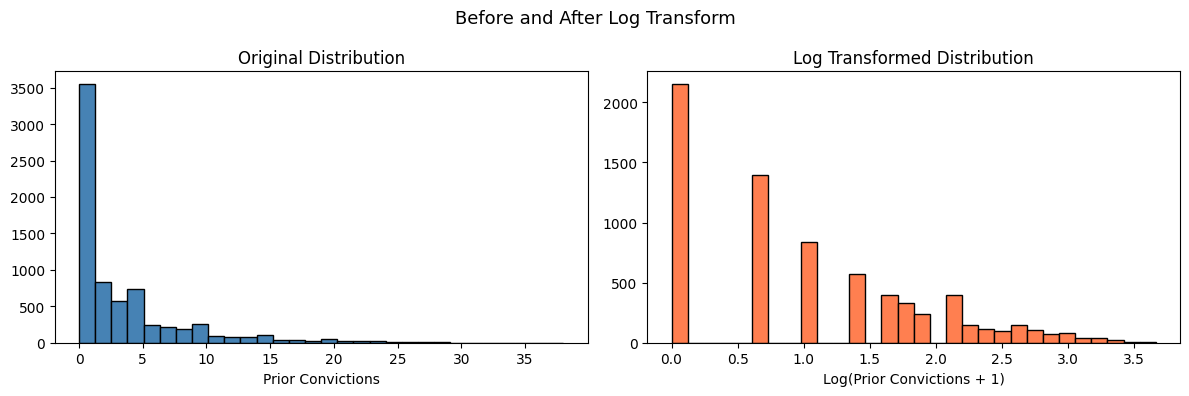

=== Linear Regression with Log Transform ===
R² Score (log scale): 0.203
RMSE (original scale): 4.602

Comparison:
R² before: 0.199 → after: 0.203
RMSE before: 4.329 → after: 4.602


In [6]:
# Cell 5 - Log Transform
# Apply log(y+1) to handle zeros
y_log = np.log1p(y)

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Original Distribution')
axes[0].set_xlabel('Prior Convictions')

axes[1].hist(y_log, bins=30, color='coral', edgecolor='black')
axes[1].set_title('Log Transformed Distribution')
axes[1].set_xlabel('Log(Prior Convictions + 1)')

plt.suptitle('Before and After Log Transform', fontsize=13)
plt.tight_layout()
plt.show()

# Train on log transformed target
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_log = LinearRegression()
lr_log.fit(X_train_scaled, y_train)

y_pred_log = lr_log.predict(X_test_scaled)

# Convert back to original scale
y_pred_original = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

r2_log = r2_score(y_test, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_original, y_pred_original))

print("=== Linear Regression with Log Transform ===")
print(f"R² Score (log scale): {r2_log:.3f}")
print(f"RMSE (original scale): {rmse_log:.3f}")
print(f"\nComparison:")
print(f"R² before: 0.199 → after: {r2_log:.3f}")
print(f"RMSE before: 4.329 → after: {rmse_log:.3f}")

## 📊 Log Transform Results

### Distribution:
The log transform made the distribution more spread out 
but it's still not perfectly normal — still right skewed.

### Model Performance:
- R² before: 0.199 → after: 0.203 — barely improved!
- RMSE before: 4.329 → after: 4.602 — actually got slightly worse!

### Why didn't it help much?
The problem isn't just the skewed target — it's that our 
features (age, sex, race, charge) simply don't contain 
enough information to predict prior convictions well.

Prior convictions are largely determined by:
- How long someone has been involved in crime
- Policing patterns in their neighborhood
- Socioeconomic factors not in our dataset

### Key Lesson:
Log transform helps when the relationship between features 
and target is multiplicative. When the features just don't 
predict the target well, no transform will fix that.

Let's try regularization next to see if it helps!

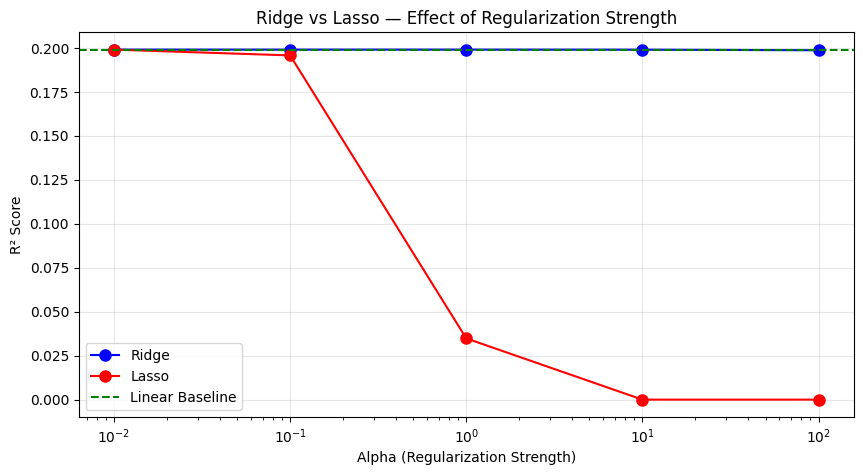

Linear Regression R²: 0.199
Best Ridge R²: 0.199 (alpha=0.01)
Best Lasso R²: 0.199 (alpha=0.01)


In [7]:
# Cell 6 - Ridge and Lasso Regularization
from sklearn.linear_model import Ridge, Lasso

# Use original (non-log) target for cleaner comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Try different alpha values
alphas = [0.01, 0.1, 1, 10, 100]
ridge_r2 = []
lasso_r2 = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_r2.append(r2_score(y_test, ridge.predict(X_test_scaled)))
    
    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train_scaled, y_train)
    lasso_r2.append(r2_score(y_test, lasso.predict(X_test_scaled)))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(alphas, ridge_r2, 'bo-', label='Ridge', markersize=8)
plt.plot(alphas, lasso_r2, 'ro-', label='Lasso', markersize=8)
plt.axhline(y=0.199, color='green', linestyle='--', label='Linear Baseline')
plt.xscale('log')
plt.xlabel('Alpha (Regularization Strength)')
plt.ylabel('R² Score')
plt.title('Ridge vs Lasso — Effect of Regularization Strength')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Best models
best_ridge = Ridge(alpha=alphas[np.argmax(ridge_r2)])
best_ridge.fit(X_train_scaled, y_train)
best_lasso = Lasso(alpha=alphas[np.argmax(lasso_r2)])
best_lasso.fit(X_train_scaled, y_train)

print(f"Linear Regression R²: 0.199")
print(f"Best Ridge R²: {max(ridge_r2):.3f} (alpha={alphas[np.argmax(ridge_r2)]})")
print(f"Best Lasso R²: {max(lasso_r2):.3f} (alpha={alphas[np.argmax(lasso_r2)]})")

## 🎛️ Ridge vs Lasso Regularization

### What is Regularization?
Regularization adds a penalty for large coefficients to prevent overfitting.
- **Ridge (L2)** — shrinks all coefficients toward zero but keeps them all
- **Lasso (L1)** — shrinks some coefficients all the way to zero (feature selection!)

### Results:
- **Ridge** stays flat at 0.199 across all alpha values — very stable
- **Lasso** drops sharply after alpha=0.1 — too much regularization kills the model
- Neither method improved over the linear baseline (0.199)

### What the chart tells us:

**Ridge (blue line — flat):**
All features contribute a little — shrinking them doesn't hurt or help much.
Ridge is stable and safe to use.

**Lasso (red line — drops sharply):**
When alpha gets too high Lasso eliminates too many features and 
the model loses all predictive power.
Best Lasso is at alpha=0.01 — barely any regularization.

### Key Insight:
The fact that regularization doesn't improve R² confirms our 
earlier finding — the problem is not overfitting. The features 
simply don't contain enough information to predict prior convictions well.

### When regularization DOES help:
- When you have many features and risk overfitting
- When features are highly correlated
- When you want automatic feature selection (Lasso)

=== 5-Fold Cross Validation Results ===

Linear Regression:
  Scores: [0.189 0.168 0.164 0.159 0.196]
  Mean R²: 0.175
  Std: 0.015

Ridge (alpha=0.01):
  Scores: [0.189 0.168 0.164 0.159 0.196]
  Mean R²: 0.175
  Std: 0.015

Lasso (alpha=0.01):
  Scores: [0.189 0.168 0.164 0.159 0.195]
  Mean R²: 0.175
  Std: 0.014



C:\Users\fo2225\AppData\Local\Temp\ipykernel_30936\1587794669.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_results.values(), labels=cv_results.keys())


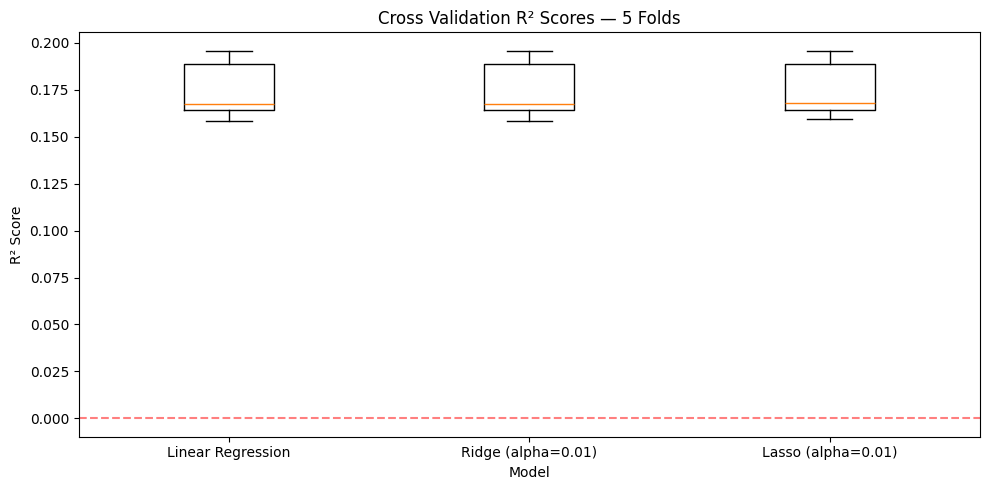

In [8]:
# Cell 7 - Cross Validation Comparison
from sklearn.model_selection import cross_val_score

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=0.01)': Ridge(alpha=0.01),
    'Lasso (alpha=0.01)': Lasso(alpha=0.01)
}

print("=== 5-Fold Cross Validation Results ===\n")
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(model, 
                            scaler.fit_transform(X), 
                            y, 
                            cv=5, 
                            scoring='r2')
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Scores: {scores.round(3)}")
    print(f"  Mean R²: {scores.mean():.3f}")
    print(f"  Std: {scores.std():.3f}\n")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys())
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Cross Validation R² Scores — 5 Folds')
ax.set_ylabel('R² Score')
ax.set_xlabel('Model')
plt.tight_layout()
plt.show()